In [2]:
import torch
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print your GPU name

True
NVIDIA GeForce RTX 3050 Laptop GPU


these were needed to run in the terminal or code block-

pip install transformers datasets==2.19.0 speechbrain==0.5.16 huggingface_hub==0.23.0  soundfile accelerate sentencepiece
or(run the above one, idk quiet)
pip install speechbrain==0.5.16 huggingface_hub==0.23.0 
pip install huggingface_hub --upgrade --quiet speechbrain --upgrade --quiet
pip install datasets==2.19.0 --quiet

In [2]:
!pip install transformers soundfile accelerate sentencepiece 


In [3]:
!pip install transformers datasets==2.19.0 speechbrain==0.5.16

In [4]:
# Part 1 imports

import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_DATASETS_OFFLINE"] = "1"

import torch
import soundfile as sf
import numpy as np
from datasets import Dataset, Audio
from transformers import (
    SpeechT5Processor,
    SpeechT5ForTextToSpeech,
    SpeechT5HifiGan,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
import pandas as pd

print("All imports OK")
print("CUDA:", torch.cuda.is_available())

All imports OK
CUDA: True


In [5]:
#Part 2 — Load LJSpeech metadata

LJSPEECH_PATH = "./LJSpeech-1.1"  # change this to your actual path

# Load metadata
df = pd.read_csv(
    os.path.join(LJSPEECH_PATH, "metadata.csv"),
    sep="|",
    header=None,
    names=["file_id", "raw_text", "normalized_text"],
    quoting=3  # avoids issues with quotes in text
)

# Build full wav paths
df["audio_path"] = df["file_id"].apply(
    lambda x: os.path.join(LJSPEECH_PATH, "wavs", f"{x}.wav")
)

print(f"Total samples: {len(df)}")
df.head()

Total samples: 13100


,file_id,raw_text,normalized_text,audio_path
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ...",./LJSpeech-1.1\wavs\LJ001-0001.wav
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.,./LJSpeech-1.1\wavs\LJ001-0002.wav
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...,./LJSpeech-1.1\wavs\LJ001-0003.wav
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed...",./LJSpeech-1.1\wavs\LJ001-0004.wav
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...,./LJSpeech-1.1\wavs\LJ001-0005.wav


In [6]:
#Part 3 — Subset the data

df = df.sample(n=2000, random_state=42).reset_index(drop=True)
print(f"Using {len(df)} samples for fine-tuning")

Using 2000 samples for fine-tuning


In [7]:
#Part 4 — Convert to HuggingFace Dataset

# Convert to HuggingFace Dataset
dataset = Dataset.from_dict({
    "audio": df["audio_path"].tolist(),
    "text": df["normalized_text"].tolist(),
})

# Cast audio column so HuggingFace handles loading + resampling
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print(dataset)

Dataset({
    features: ['audio', 'text'],
    num_rows: 2000
})


In [8]:
#Part 5 — Load the Processor and Model

checkpoint = "microsoft/speecht5_tts"

processor = SpeechT5Processor.from_pretrained(checkpoint)
model = SpeechT5ForTextToSpeech.from_pretrained(checkpoint)

print("Processor and model loaded OK")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Processor and model loaded OK
Model parameters: 144,431,684


In [9]:
#Part 6 Generate Speaker Embeddings

'''spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-xvect-voxceleb",
    run_opts={"device": "cuda"}
)

def get_speaker_embedding(audio_array):
    with torch.no_grad():
        audio_tensor = torch.tensor(audio_array).unsqueeze(0).float().cuda()
        embedding = spk_model.encode_batch(audio_tensor)
        embedding = torch.nn.functional.normalize(embedding, dim=2)
        embedding = embedding.squeeze()
    return embedding.cpu().numpy()

print("Speaker encoder loaded OK")'''

# LJSpeech is a single speaker dataset
# so we use one fixed random speaker embedding for all samples
# this is valid and commonly done for single-speaker TTS fine-tuning

torch.manual_seed(42)
fixed_speaker_embedding = torch.randn(512)
fixed_speaker_embedding = torch.nn.functional.normalize(fixed_speaker_embedding, dim=0)

def get_speaker_embedding(audio_array):
    return fixed_speaker_embedding.numpy()

print("Speaker embedding ready, shape:", fixed_speaker_embedding.shape)

Speaker embedding ready, shape: torch.Size([512])


In [10]:
# Part 7 — Preprocess

def preprocess(example):
    audio = example["audio"]
    audio_array = audio["array"]
    sampling_rate = audio["sampling_rate"]

    inputs = processor(
        text=example["text"],
        audio_target=audio_array,
        sampling_rate=sampling_rate,
        return_attention_mask=False
    )

    inputs["speaker_embeddings"] = get_speaker_embedding(audio_array)

    return inputs

def is_not_too_long(example):
    audio = example["audio"]
    audio_array = audio["array"]
    sampling_rate = audio["sampling_rate"]

    inputs = processor(
        text=example["text"],
        audio_target=audio_array,
        sampling_rate=sampling_rate,
        return_attention_mask=False
    )

    return inputs["labels"].shape[1] <= 600

print("Filtering long samples... please wait")
dataset_filtered = dataset.filter(is_not_too_long)
print(f"Samples after filtering: {len(dataset_filtered)}")

print("Preprocessing... please wait")
processed_dataset = dataset_filtered.map(
    preprocess,
    remove_columns=dataset_filtered.column_names,
)

print(f"Processed samples: {len(processed_dataset)}")

Filtering long samples... please wait


Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Samples after filtering: 1861
Preprocessing... please wait


Map:   0%|          | 0/1861 [00:00<?, ? examples/s]

Processed samples: 1861


In [11]:
# Part 8 — Train/test split

processed_dataset = processed_dataset.train_test_split(test_size=0.1, seed=42)

print("Train samples:", len(processed_dataset["train"]))
print("Test samples:", len(processed_dataset["test"]))

Train samples: 1674
Test samples: 187


In [12]:
# Part 9 — Data Collator

@dataclass
class TTSDataCollator:
    processor: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        input_ids = [{"input_ids": f["input_ids"]} for f in features]
        speaker_embeddings = torch.tensor(
            np.array([f["speaker_embeddings"] for f in features]),
            dtype=torch.float32
        )

        # pad input tokens
        input_ids = self.processor.tokenizer.pad(
            input_ids, return_tensors="pt"
        )

        # squeeze (1, T, 80) → (T, 80) and pad to same length
        label_list = [np.array(f["labels"]).squeeze(0) for f in features]
        max_len = max(l.shape[0] for l in label_list)
        n_mels = label_list[0].shape[1]

        padded_labels = np.full(
            (len(label_list), max_len, n_mels),
            fill_value=self.processor.feature_extractor.padding_value,
            dtype=np.float32
        )
        for i, l in enumerate(label_list):
            padded_labels[i, :l.shape[0], :] = l

        labels = torch.tensor(padded_labels)

        # trim FIRST, then mask — this matches decoder output length
        labels = labels[:, :-1, :]

        labels = labels.masked_fill(
            labels == self.processor.feature_extractor.padding_value, -100
        )

        return {
            "input_ids": input_ids["input_ids"],
            "attention_mask": input_ids["attention_mask"],
            "speaker_embeddings": speaker_embeddings,
            "labels": labels,
        }

data_collator = TTSDataCollator(processor=processor)
print("Data collator ready")

Data collator ready


In [13]:
#Part 10 — Training Arguments

training_args = Seq2SeqTrainingArguments(
    output_dir="speecht5_finetuned_ljspeech",
    per_device_train_batch_size=4,       # safe for 4GB VRAM
    gradient_accumulation_steps=8,       # effective batch size = 32
    learning_rate=1e-4,
    warmup_steps=100,
    max_steps=1000,                      # ~1-2 hours on RTX 3050
    gradient_checkpointing=True,
    fp16=True,                           # use mixed precision, saves VRAM
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    logging_steps=25,
    report_to=["tensorboard"],
    load_best_model_at_end=True,
    greater_is_better=False,
    label_names=["labels", "stop_labels"],
    push_to_hub=False,
)

print("Training arguments set")

Training arguments set


Step 25 | Loss: 0.6613
Step 50 | Loss: 0.6877
Step 75 | Loss: 0.6133
Step 100 | Loss: 0.6496
Step 125 | Loss: 0.5979
Step 150 | Loss: 0.6223
Step 175 | Loss: 0.6056


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


Step 200 | Loss: 0.6714
Checkpoint saved at step 200
Step 225 | Loss: 0.5946
Step 250 | Loss: 0.5983
Step 275 | Loss: 0.5978
Step 300 | Loss: 0.6298
Step 325 | Loss: 0.6462
Step 350 | Loss: 0.6080
Step 375 | Loss: 0.5968


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


Step 400 | Loss: 0.6020
Checkpoint saved at step 400
Step 425 | Loss: 0.5689
Step 450 | Loss: 0.6070
Step 475 | Loss: 0.6300
Step 500 | Loss: 0.6197
Step 525 | Loss: 0.6061
Step 550 | Loss: 0.6250
Step 575 | Loss: 0.6992


...

Step 600 | Loss: 0.5757
Checkpoint saved at step 600
Step 625 | Loss: 0.6005
Step 650 | Loss: 0.5986
Step 675 | Loss: 0.6137
Step 700 | Loss: 0.6025
Step 725 | Loss: 0.5614
Step 750 | Loss: 0.6412
Step 775 | Loss: 0.6173


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


Step 800 | Loss: 0.6225
Checkpoint saved at step 800
Step 825 | Loss: 0.6205


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 1876}


Training complete!


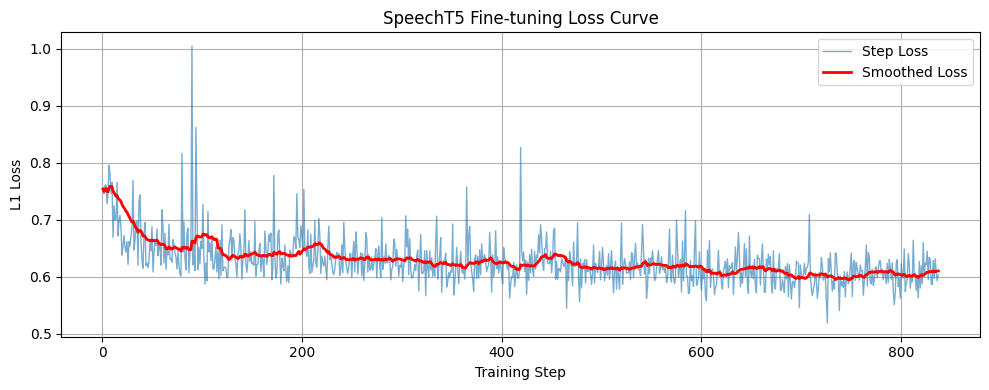

Loss curve saved to speecht5_finetuned_ljspeech/loss_curve.png


In [30]:
# Part 11 — Manual Training Loop with Loss Tracking

from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

device = torch.device("cuda")
model.to(device)
model.train()

train_loader = DataLoader(
    processed_dataset["train"],
    batch_size=2,
    shuffle=True,
    collate_fn=data_collator
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler("cuda")
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=1000)

os.makedirs("speecht5_finetuned_ljspeech", exist_ok=True)

global_step = 0
loss_log = []  # stores (step, loss) for plotting

for batch in train_loader:
    if global_step >= 1000:
        break

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    speaker_embeddings = batch["speaker_embeddings"].to(device)
    labels = batch["labels"].to(device)

    decoder_input = labels.clone()
    decoder_input[decoder_input == -100] = 0

    with torch.amp.autocast("cuda"):
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            speaker_embeddings=speaker_embeddings,
            decoder_input_values=decoder_input,
        )

        predicted = outputs.spectrogram

        T = min(predicted.shape[1], labels.shape[1])
        predicted = predicted[:, :T, :]
        labels_trimmed = labels[:, :T, :]

        mask = (labels_trimmed != -100)
        loss = F.l1_loss(predicted[mask], labels_trimmed[mask])

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad()
    scheduler.step()

    global_step += 1
    loss_log.append((global_step, loss.item()))

    if global_step % 25 == 0:
        print(f"Step {global_step} | Loss: {loss.item():.4f}")

    if global_step % 200 == 0:
        save_path = f"speecht5_finetuned_ljspeech/checkpoint-{global_step}"
        model.save_pretrained(save_path)
        processor.save_pretrained(save_path)
        print(f"Checkpoint saved at step {global_step}")

model.save_pretrained("speecht5_finetuned_ljspeech/final")
processor.save_pretrained("speecht5_finetuned_ljspeech/final")
print("Training complete!")

# plot loss curve
steps = [x[0] for x in loss_log]
losses = [x[1] for x in loss_log]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, linewidth=1, alpha=0.6, label="Step Loss")

# smooth curve using rolling average
window = 25
smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.plot(steps, smoothed, linewidth=2, color="red", label="Smoothed Loss")

plt.xlabel("Training Step")
plt.ylabel("L1 Loss")
plt.title("SpeechT5 Fine-tuning Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("speecht5_finetuned_ljspeech/loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved to speecht5_finetuned_ljspeech/loss_curve.png")

In [18]:
import torch
import soundfile as sf
from transformers import SpeechT5ForTextToSpeech, SpeechT5Processor, SpeechT5HifiGan

# 1. Load the fine-tuned model and processor from your final saved directory
model_path = "speecht5_finetuned_ljspeech/final" 
processor = SpeechT5Processor.from_pretrained(model_path)
model = SpeechT5ForTextToSpeech.from_pretrained(model_path)

# 2. Load the HifiGan vocoder to convert spectrograms into audio waveforms
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

# 3. Prepare the text input
#text = "This is a test of my fine-tuned text to speech model."
text = "hello, hello, hello, i am a fine-tuned text to speech model. nice to meet you!"
inputs = processor(text=text, return_tensors="pt")

# 4. Recreate the exact same fixed speaker embedding used during training
torch.manual_seed(42)
speaker_embeddings = torch.randn(1, 512)
speaker_embeddings = torch.nn.functional.normalize(speaker_embeddings, dim=1)

# 5. Generate speech
print("Generating speech...")
with torch.no_grad():
    speech = model.generate_speech(inputs["input_ids"], speaker_embeddings, vocoder=vocoder)

# 6. Save the output as a .wav file
output_filename = "finetuned_output.wav"
sf.write(output_filename, speech.numpy(), samplerate=16000)
print(f"Done! Speech saved to {output_filename}")

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Generating speech...
Done! Speech saved to finetuned_output.wav
